# Lab Assignment 5

From Bag-of-Words to Word2Vec (CBOW & Skip-gram)

**Name:** Akshat  
**Roll number:** 12340160

## Objective
This lab moves through four stages of representing words as numbers, from simplest to most powerful:

1. **Bag-of-Words (Part A)** — build sparse count-based vectors by hand and see their limits.
2. **Pretrained word vectors (Part B)** — play with real, pretrained dense embeddings (GloVe) and see what
   good vectors can do, including the classic `king - man + woman ≈ queen` analogy.
3. **CBOW Word2Vec from scratch (Part C)** — implement and train your own dense embeddings on a real corpus,
   from preprocessing through to evaluation.
4. **Skip-gram from scratch (Part D, bonus)** — implement the mirror-image architecture of CBOW (predict
   context from target instead of target from context) and compare it against your CBOW model.

## Submission
- Complete all `TODO` sections and all markdown answers.
- Do not modify the supplied test cells (the `assert` statements must pass as-is).
- Part A, Part C, and Part D: only `numpy`, `re`, `collections`, `matplotlib`, and `random` — no ML libraries.
  Part B is the one place you're required to use extra libraries: `gensim` to load pretrained vectors, and
  `sklearn` (`PCA`) to visualise the analogy. `sklearn` is also allowed in the Part C bonus task.
- Run **Kernel > Restart & Run All** before submitting the completed `.ipynb` file.
- Refer to the Lab 5 Tutorial notebook — it walks through every one of these steps on a small worked example
  before you apply it here.


# Reference Code from the Tutorial (Toy Example)

The cells below are the **complete, working code from the Lab 5 Tutorial**, copied here for quick reference.
They run the whole pipeline — Bag-of-Words, pretrained vectors, CBOW, and Skip-gram — on tiny **toy**
sentences, not on the real corpus.

**You still have to do the work yourself for the actual assignment.** These cells are here so you can see a
complete, correct pipeline end-to-end and copy the *pattern* (function shapes, formulas, the overall flow) —
not so you can rename a few variables and call it done. Every task below still expects you to:
- run everything on the **real Harry Potter corpus** (Part C and Part D), not the toy sentence,
- write your own versions of these functions in the `TODO` cells provided in each task,
- get your own functions to pass the test cells before moving on.

If a function name in your task cell doesn't match the reference below (e.g. `forward` vs. `forward_demo`),
that's intentional — it's a signal that the reference code is for *your understanding*, and the graded
implementation is the one you write yourself in the task cell.


### Reference: Part A (Bag-of-Words)

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

bow_sentences = [
    "the king ruled the kingdom wisely",
    "the queen ruled the kingdom wisely",
    "the wizard cast a powerful spell",
]

bow_vocab_ref = sorted(set(w for s in bow_sentences for w in s.lower().split()))
print("Vocabulary:", bow_vocab_ref)


def build_bow_vector_demo(tokens, vocab):
    vec = np.zeros(len(vocab), dtype=int)
    for t in tokens:
        if t in vocab:
            vec[vocab.index(t)] += 1
    return vec


bow_vecs_ref = [build_bow_vector_demo(s.lower().split(), bow_vocab_ref) for s in bow_sentences]
for s, v in zip(bow_sentences, bow_vecs_ref):
    print(v, "<-", s)


def bow_cosine_similarity_demo(v1, v2):
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return 0.0
    return float(np.dot(v1, v2) / denom)


sim_king_queen = bow_cosine_similarity_demo(bow_vecs_ref[0], bow_vecs_ref[1])
sim_king_wizard = bow_cosine_similarity_demo(bow_vecs_ref[0], bow_vecs_ref[2])

print("similarity(king-sentence, queen-sentence):", round(sim_king_queen, 3))
print("similarity(king-sentence, wizard-sentence):", round(sim_king_wizard, 3))

Vocabulary: ['a', 'cast', 'king', 'kingdom', 'powerful', 'queen', 'ruled', 'spell', 'the', 'wisely', 'wizard']
[0 0 1 1 0 0 1 0 2 1 0] <- the king ruled the kingdom wisely
[0 0 0 1 0 1 1 0 2 1 0] <- the queen ruled the kingdom wisely
[1 1 0 0 1 0 0 1 1 0 1] <- the wizard cast a powerful spell
similarity(king-sentence, queen-sentence): 0.875
similarity(king-sentence, wizard-sentence): 0.289


### Reference: Part B (Pretrained Vectors)

Vocabulary size: 400000
similarity(king, queen):    0.784
similarity(king, cabbage):  0.113
     queen  0.852
    throne  0.766
    prince  0.759
  daughter  0.747
 elizabeth  0.746


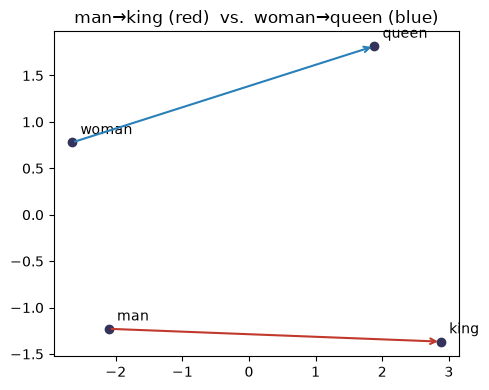

Cosine similarity between the two arrows: 0.968


In [2]:
# Downloads ~66MB the first time (cached afterwards). Requires internet access (e.g. Google Colab).
import gensim.downloader as glove_api

word_vectors_demo = glove_api.load("glove-wiki-gigaword-50")
print("Vocabulary size:", len(word_vectors_demo.index_to_key))

print("similarity(king, queen):   ", round(word_vectors_demo.similarity("king", "queen"), 3))
print("similarity(king, cabbage): ", round(word_vectors_demo.similarity("king", "cabbage"), 3))

analogy_result = word_vectors_demo.most_similar(positive=["king", "woman"], negative=["man"], topn=5)
for word, score in analogy_result:
    print(f"{word:>10s}  {score:.3f}")

from sklearn.decomposition import PCA

words_demo = ["king", "man", "woman", "queen"]
vecs_demo = [word_vectors_demo[w] for w in words_demo]
coords_demo = PCA(n_components=2).fit_transform(vecs_demo)

plt.figure(figsize=(5, 4))
for word, (x, y) in zip(words_demo, coords_demo):
    plt.scatter(x, y, color="#33335c")
    plt.annotate(word, (x, y), textcoords="offset points", xytext=(6, 6))

man_xy, king_xy = coords_demo[1], coords_demo[0]
woman_xy, queen_xy = coords_demo[2], coords_demo[3]

plt.annotate("", xy=king_xy, xytext=man_xy, arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.5))
plt.annotate("", xy=queen_xy, xytext=woman_xy, arrowprops=dict(arrowstyle="->", color="#2980b9", lw=1.5))
plt.title("man→king (red)  vs.  woman→queen (blue)")
plt.tight_layout()
plt.show()

arrow1 = king_xy - man_xy
arrow2 = queen_xy - woman_xy
cos_between_arrows = np.dot(arrow1, arrow2) / (np.linalg.norm(arrow1) * np.linalg.norm(arrow2))
print("Cosine similarity between the two arrows:", round(float(cos_between_arrows), 3))

### Reference: Part C (CBOW)

Tokens: ['the', 'boy', 'who', 'lived', 'came', 'to', 'die', 'but', 'the', 'boy', 'who', 'lived', 'came', 'back']


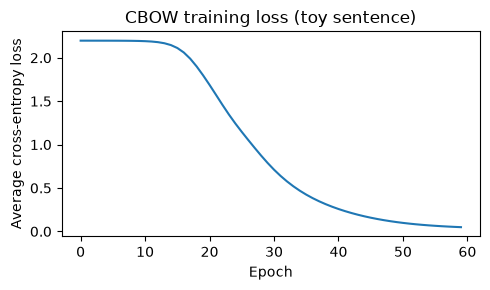

boy -> [('the', 0.34219999168431425), ('to', 0.11425357292595284), ('who', 0.10231984489435343)]
lived -> [('the', 0.15814229618384848), ('who', -0.04590726037355162), ('die', -0.2491430303618136)]
came -> [('to', 0.6959686773639484), ('back', 0.44648656083487076), ('but', 0.02510890821290452)]


In [3]:
def clean_text_demo(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_demo(text):
    return text.split()


raw_sentence = "The boy who lived came to die, but the boy who lived came back."
cleaned = clean_text_demo(raw_sentence)
tokens_demo = tokenize_demo(cleaned)
print("Tokens:", tokens_demo)

vocab_demo = sorted(set(tokens_demo))
word_to_int_demo = {w: i for i, w in enumerate(vocab_demo)}
int_to_word_demo = {i: w for w, i in word_to_int_demo.items()}


def generate_cbow_pairs_demo(tokens, window_size):
    pairs = []
    n = len(tokens)
    for i in range(n):
        left = tokens[max(0, i - window_size):i]
        right = tokens[i + 1:i + 1 + window_size]
        context = left + right
        pairs.append((context, tokens[i]))
    return pairs


pairs_demo = generate_cbow_pairs_demo(tokens_demo, window_size=2)


def stable_softmax_demo(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)


def init_params_demo(vocab_size, embedding_dim):
    W1 = np.random.randn(vocab_size, embedding_dim) * 0.01
    W2 = np.random.randn(embedding_dim, vocab_size) * 0.01
    return W1, W2


def forward_demo(context_idxs, W1, W2):
    h = np.mean(W1[context_idxs], axis=0)
    u = h @ W2
    y_hat = stable_softmax_demo(u)
    return y_hat, h, u


def cross_entropy_loss_demo(y_hat, target_idx):
    eps = 1e-12
    return -np.log(y_hat[target_idx] + eps)


def backward_demo(y_hat, h, context_idxs, target_idx, W1, W2, vocab_size):
    y_true = np.zeros(vocab_size)
    y_true[target_idx] = 1.0
    e = y_hat - y_true
    dW2 = np.outer(h, e)
    dh = W2 @ e
    dW1 = np.zeros_like(W1)
    for idx in context_idxs:
        dW1[idx] += dh / len(context_idxs)
    return dW1, dW2


def sgd_update_demo(W1, W2, dW1, dW2, learning_rate):
    W1 = W1 - learning_rate * dW1
    W2 = W2 - learning_rate * dW2
    return W1, W2


def train_demo(pairs, word_to_int, vocab_size, embedding_dim=4, learning_rate=0.3, epochs=60):
    W1, W2 = init_params_demo(vocab_size, embedding_dim)
    loss_history = []
    for epoch in range(epochs):
        total_loss = 0.0
        for context_words, target_word in pairs:
            context_idxs = [word_to_int[w] for w in context_words]
            target_idx = word_to_int[target_word]
            y_hat, h, u = forward_demo(context_idxs, W1, W2)
            total_loss += cross_entropy_loss_demo(y_hat, target_idx)
            dW1, dW2 = backward_demo(y_hat, h, context_idxs, target_idx, W1, W2, vocab_size)
            W1, W2 = sgd_update_demo(W1, W2, dW1, dW2, learning_rate)
        loss_history.append(total_loss / len(pairs))
    return W1, W2, loss_history


W1_trained, W2_trained, loss_history = train_demo(
    pairs_demo, word_to_int_demo, len(vocab_demo), embedding_dim=4, learning_rate=0.3, epochs=60
)

plt.figure(figsize=(5, 3))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Average cross-entropy loss")
plt.title("CBOW training loss (toy sentence)")
plt.tight_layout()
plt.show()


def cosine_similarity_demo(v1, v2):
    denom = (np.linalg.norm(v1) * np.linalg.norm(v2))
    if denom == 0:
        return 0.0
    return float(np.dot(v1, v2) / denom)


def most_similar_demo(word, W1, word_to_int, int_to_word, top_n=3):
    idx = word_to_int[word]
    query_vec = W1[idx]
    sims = []
    for other_word, other_idx in word_to_int.items():
        if other_word == word:
            continue
        sims.append((other_word, cosine_similarity_demo(query_vec, W1[other_idx])))
    sims.sort(key=lambda pair: pair[1], reverse=True)
    return sims[:top_n]


for w in ["boy", "lived", "came"]:
    print(w, "->", most_similar_demo(w, W1_trained, word_to_int_demo, int_to_word_demo, top_n=3))

### Reference: Part D (Skip-gram)

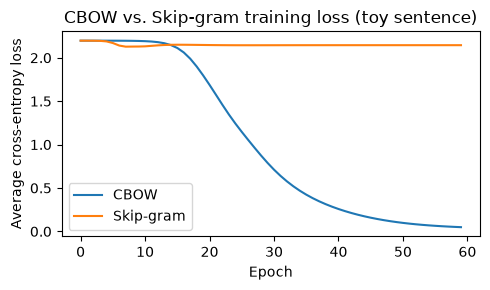

boy -> [('who', 0.3216021103051045), ('the', 0.31977258661091224), ('came', 0.2107923653813517)]
lived -> [('came', 0.3788263684101236), ('who', 0.24384051196962558), ('back', 0.2414261178108962)]
came -> [('lived', 0.3788263684101236), ('boy', 0.2107923653813517), ('to', 0.08120567726868648)]


In [4]:
def generate_skipgram_pairs_demo(tokens, window_size):
    pairs = []
    n = len(tokens)
    for i in range(n):
        left = tokens[max(0, i - window_size):i]
        right = tokens[i + 1:i + 1 + window_size]
        context = left + right
        for c in context:
            pairs.append((tokens[i], c))
    return pairs


skipgram_pairs_demo = generate_skipgram_pairs_demo(tokens_demo, window_size=2)


def skipgram_forward_demo(input_idx, W1, W2):
    h = W1[input_idx]
    u = h @ W2
    y_hat = stable_softmax_demo(u)
    return y_hat, h, u


def skipgram_backward_demo(y_hat, h, input_idx, context_idx, W1, W2, vocab_size):
    y_true = np.zeros(vocab_size)
    y_true[context_idx] = 1.0
    e = y_hat - y_true
    dW2 = np.outer(h, e)
    dh = W2 @ e
    dW1 = np.zeros_like(W1)
    dW1[input_idx] = dh
    return dW1, dW2


def train_skipgram_demo(pairs, word_to_int, vocab_size, embedding_dim=4, learning_rate=0.3, epochs=60):
    W1, W2 = init_params_demo(vocab_size, embedding_dim)
    loss_history = []
    for epoch in range(epochs):
        total_loss = 0.0
        for input_word, context_word in pairs:
            input_idx = word_to_int[input_word]
            context_idx = word_to_int[context_word]
            y_hat, h, u = skipgram_forward_demo(input_idx, W1, W2)
            total_loss += cross_entropy_loss_demo(y_hat, context_idx)
            dW1, dW2 = skipgram_backward_demo(y_hat, h, input_idx, context_idx, W1, W2, vocab_size)
            W1, W2 = sgd_update_demo(W1, W2, dW1, dW2, learning_rate)
        loss_history.append(total_loss / len(pairs))
    return W1, W2, loss_history


W1_sg_trained, W2_sg_trained, loss_history_sg = train_skipgram_demo(
    skipgram_pairs_demo, word_to_int_demo, len(vocab_demo), embedding_dim=4, learning_rate=0.3, epochs=60
)

plt.figure(figsize=(5, 3))
plt.plot(loss_history, label="CBOW")
plt.plot(loss_history_sg, label="Skip-gram")
plt.xlabel("Epoch")
plt.ylabel("Average cross-entropy loss")
plt.title("CBOW vs. Skip-gram training loss (toy sentence)")
plt.legend()
plt.tight_layout()
plt.show()

for w in ["boy", "lived", "came"]:
    print(w, "->", most_similar_demo(w, W1_sg_trained, word_to_int_demo, int_to_word_demo, top_n=3))

**Reminder:** everything above ran on a one-sentence toy example. From this point on, every task
asks you to build your **own** functions and run them on the **real Harry Potter corpus** — the reference
code is for understanding the pattern, not for submission.


# Part A: Bag-of-Words

Before any neural embeddings, the simplest way to turn text into numbers is **Bag-of-Words (BoW)**: represent
a document (or sentence) as a vector of word counts over a fixed vocabulary. Word order is thrown away —
only "which words, how many times" survives.

### Task A1: Build BoW vectors

1. Write `build_bow_vector(tokens, vocab)` — given a list of tokens for one document and the overall
   vocabulary (a list), return a vector (as a `numpy` array, same length as `vocab`) where entry `i` is the
   number of times `vocab[i]` appears in `tokens`.
2. Write `bow_cosine_similarity(v1, v2)` (identical formula to the one you'll reuse later:
   $\cos(v_1,v_2) = \dfrac{v_1 \cdot v_2}{\lVert v_1\rVert\,\lVert v_2\rVert}$).
3. Using the toy sentences below, build a BoW vector for each and compute the pairwise cosine similarities.


In [5]:
import numpy as np

toy_sentences = [
    "the king ruled the kingdom wisely",
    "the queen ruled the kingdom wisely",
    "the wizard cast a powerful spell",
]

bow_vocab = sorted(set(w for s in toy_sentences for w in s.lower().split()))


def build_bow_vector(tokens, vocab):
    vec = np.zeros(len(vocab), dtype=int)
    for t in tokens:
        if t in vocab:
            vec[vocab.index(t)] += 1
    return vec


def bow_cosine_similarity(v1, v2):
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return 0.0
    return float(np.dot(v1, v2) / denom)


# --- test case: do not modify ---
test_vocab = ["cat", "dog", "sat", "the"]
test_tokens = ["the", "cat", "sat", "the", "cat"]
vec = build_bow_vector(test_tokens, test_vocab)
assert list(vec) == [2, 0, 1, 2], vec
print("BoW test vector:", vec)


BoW test vector: [2 0 1 2]


In [6]:
bow_vectors = [build_bow_vector(s.lower().split(), bow_vocab) for s in toy_sentences]

print("Vocabulary:", bow_vocab)
for s, v in zip(toy_sentences, bow_vectors):
    print(v, "<-", s)

print()
print("similarity(sentence 1, sentence 2):", round(bow_cosine_similarity(bow_vectors[0], bow_vectors[1]), 3))
print("similarity(sentence 1, sentence 3):", round(bow_cosine_similarity(bow_vectors[0], bow_vectors[2]), 3))


Vocabulary: ['a', 'cast', 'king', 'kingdom', 'powerful', 'queen', 'ruled', 'spell', 'the', 'wisely', 'wizard']
[0 0 1 1 0 0 1 0 2 1 0] <- the king ruled the kingdom wisely
[0 0 0 1 0 1 1 0 2 1 0] <- the queen ruled the kingdom wisely
[1 1 0 0 1 0 0 1 1 0 1] <- the wizard cast a powerful spell

similarity(sentence 1, sentence 2): 0.875
similarity(sentence 1, sentence 3): 0.289


### Task A2: Why Bag-of-Words falls short (write your answer)

The "king" sentence and the "queen" sentence share every word except one (`king` vs. `queen`), so their BoW
cosine similarity should come out fairly high. Now consider the words `king` and `queen` **on their own**,
as individual BoW-style one-hot vectors (each word is its own dimension).

**Question:** What is `cosine_similarity(one_hot("king"), one_hot("queen"))`? Explain *why* BoW / one-hot
word representations can never capture that "king" and "queen" are related words, no matter how large the
corpus is. (This motivates Part B and Part C — we need *dense* vectors where similarity is learned, not
one word per independent dimension.)

**Answer:**

`cosine_similarity(one_hot("king"), one_hot("queen")) = 0`.

Each one-hot vector holds a single 1 with zeros everywhere else, and the two 1s sit at different positions,
so the dot product is 0. Both norms are 1, so the cosine is 0 as well. The same argument works for any two
different words, which means every pair of distinct words in a one-hot scheme is exactly orthogonal.

The real issue is what the dimensions stand for. In BoW each word owns one dimension and nothing else uses
it. The position of the 1 comes from where the word landed in the sorted vocabulary, which has nothing to do
with how the word is used. Feeding in more text only makes the vocabulary longer and the vectors sparser. It
never creates a coordinate that `king` and `queen` could share, so their similarity stays at 0 no matter how
large the corpus is, and `king` ends up as far from `queen` as it is from `spaceship`.

Sentence level BoW appears to work only because two sentences can repeat the same word literally. The two
royal sentences scored 0.875 because they share five of their six words. Word level similarity needs
something different, a small set of dimensions that many words share and whose values are learned from the
contexts a word appears in. That is what Part B and Part C build.


# Part B: Playing with Pretrained Word Vectors

Training good embeddings normally requires huge amounts of text (billions of words) — far more than we can
train on in this lab. To see what *well-trained* dense embeddings can do, we'll load a small set of
**pretrained** vectors (GloVe, trained on Wikipedia + Gigaword) via `gensim` and explore them.

> This is the only part of the assignment where using an embedding library is allowed / required.


In [7]:
# This downloads ~66MB the first time you run it (cached after that). Needs internet access (e.g. Colab).
import gensim.downloader as glove_api

word_vectors = glove_api.load("glove-wiki-gigaword-50")
print("Vocabulary size:", len(word_vectors.index_to_key))

Vocabulary size: 400000


### Task B1: Similarity with real vectors

Using `word_vectors.similarity(word1, word2)`, compare a few pairs, e.g. `("king", "queen")`,
`("king", "cabbage")`, `("happy", "joyful")`. Print all three.


In [8]:
for w1, w2 in [("king", "queen"), ("king", "cabbage"), ("happy", "joyful")]:
    print(f"similarity({w1}, {w2}):", round(float(word_vectors.similarity(w1, w2)), 3))


similarity(king, queen): 0.784
similarity(king, cabbage): 0.113
similarity(happy, joyful): 0.555


### Task B2: The classic analogy — `king - man + woman ≈ queen`

`gensim`'s `most_similar` supports vector arithmetic directly:

```python
word_vectors.most_similar(positive=["king", "woman"], negative=["man"], topn=5)
```

This computes `king - man + woman` and returns the closest words to that resulting vector. Run it and confirm
`"queen"` appears near the top.


In [9]:
for word, score in word_vectors.most_similar(positive=["king", "woman"], negative=["man"], topn=5):
    print(f"{word:>10s}  {score:.3f}")


     queen  0.852
    throne  0.766
    prince  0.759
  daughter  0.747
 elizabeth  0.746


### Task B3: Try two analogies of your own

Pick two more analogies in the same `positive=[...] , negative=[...]` style (e.g. country-capital pairs like
`paris - france + italy`, or verb-tense pairs). Run them and report whether the top result matched your
expectation.


In [10]:
my_analogies = [
    (["paris", "italy"], ["france"], "rome"),
    (["walking", "swim"], ["walk"], "swimming"),
]

for positive, negative, expected in my_analogies:
    print(f"{positive[0]} - {negative[0]} + {positive[1]}   (expected: {expected})")
    for word, score in word_vectors.most_similar(positive=positive, negative=negative, topn=3):
        print(f"   {word:>12s}  {score:.3f}")
    print()


paris - france + italy   (expected: rome)
           rome  0.847
          milan  0.777
          turin  0.767

walking - walk + swim   (expected: swimming)
       swimming  0.807
       swimmers  0.750
          swims  0.745



### Task B4: Visualise the analogy (the "parallelogram" picture)

Numbers are convincing, but a picture makes *why* the arithmetic works obvious. Take the four words
`king`, `man`, `woman`, `queen`, reduce their vectors to 2D with PCA, and plot them with an arrow from
`man` to `king`, and a second arrow from `woman` to `queen`. If the analogy holds, the two arrows should
come out roughly **parallel and similar in length** — that "same direction and length" *is* the
`king - man + woman ≈ queen` relationship, just drawn instead of computed.


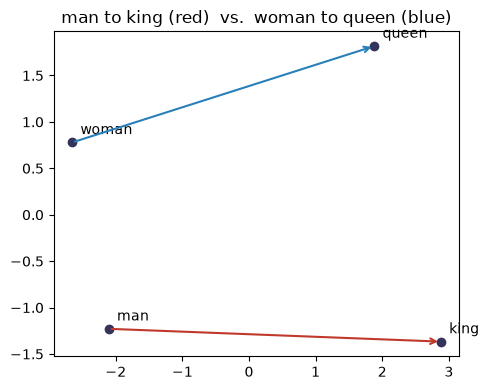

Cosine between the two arrows: 0.968
Length of man -> king:   4.987
Length of woman -> queen: 4.651


In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

analogy_words = ["king", "man", "woman", "queen"]
analogy_vecs = [word_vectors[w] for w in analogy_words]
coords = PCA(n_components=2).fit_transform(analogy_vecs)

king_xy, man_xy, woman_xy, queen_xy = coords

plt.figure(figsize=(5, 4))
for word, (x, y) in zip(analogy_words, coords):
    plt.scatter(x, y, color="#33335c")
    plt.annotate(word, (x, y), textcoords="offset points", xytext=(6, 6))

plt.annotate("", xy=king_xy, xytext=man_xy, arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.5))
plt.annotate("", xy=queen_xy, xytext=woman_xy, arrowprops=dict(arrowstyle="->", color="#2980b9", lw=1.5))
plt.title("man to king (red)  vs.  woman to queen (blue)")
plt.tight_layout()
plt.show()

arrow_king = king_xy - man_xy
arrow_queen = queen_xy - woman_xy
cos_arrows = np.dot(arrow_king, arrow_queen) / (np.linalg.norm(arrow_king) * np.linalg.norm(arrow_queen))

print("Cosine between the two arrows:", round(float(cos_arrows), 3))
print("Length of man -> king:  ", round(float(np.linalg.norm(arrow_king)), 3))
print("Length of woman -> queen:", round(float(np.linalg.norm(arrow_queen)), 3))


**Your observation (fill in):** Do the two arrows look roughly parallel and similar in length? If not
exactly, what do you think causes the distortion (hint: think about what PCA is doing to a 50-dimensional
vector space)?

**Answer:**

The two arrows come out close to parallel and close to the same length. The cosine between them is 0.968 and
the lengths are 4.99 for `man -> king` and 4.65 for `woman -> queen`, so the directions agree well and the
lengths differ by about seven percent.

Most of the mismatch is caused by PCA. The real vectors live in 50 dimensions and PCA keeps only the two
directions along which these four vectors vary the most, so whatever the analogy used in the other 48
directions is flattened away. Two arrows that are almost parallel in 50 dimensions can look slightly
different once they are squashed into a plane, because the components on which they disagreed have been
dropped and the surviving components are rescaled to fill the plot. The analogy is also only approximate to
begin with. `king - man + woman` lands near `queen` but not exactly on it, since `king` carries meaning about
monarchy and history that has nothing to do with gender.


**Your reflection (fill in):**

- Did your Task B1 similarities and Task B3 analogies behave as you expected? Any surprises?
- Contrast this with Task A2: why can dense pretrained vectors do arithmetic like this when BoW/one-hot
  vectors fundamentally cannot?

**Answer:**

- The Task B1 numbers came out as expected. `king` and `queen` scored 0.784, `happy` and `joyful` scored
  0.555, and `king` and `cabbage` scored 0.113. The surprise was that two near synonyms like `happy` and
  `joyful` scored lower than `king` and `queen`. GloVe is built from co-occurrence counts, so what it
  rewards is appearing in the same kinds of sentences, and `king` and `queen` share contexts about thrones,
  kingdoms and royal titles far more often than `joyful` appears at all. `joyful` is a rarer word, so its
  vector rests on much less evidence.
- Both Task B3 analogies worked. `paris - france + italy` returned `rome` at 0.847 with `milan` and `turin`
  behind it, and `walking - walk + swim` returned `swimming` at 0.807. The top result matched my expectation
  in both cases, and the runners up are sensible too, being other Italian cities and other forms of the same
  verb.
- The contrast with Task A2 is the whole point of dense vectors. One-hot vectors give every word its own
  dimension and no shared coordinates, so subtracting or adding them just produces another sparse vector
  whose nearest neighbour means nothing. GloVe gives each word 50 dense numbers learned from co-occurrence,
  so a property such as gender or "capital city of" ends up stored as a roughly consistent direction that
  many word pairs share. Once a property is a direction in the space, adding and subtracting it moves you to
  another word carrying that property, which is exactly what the analogy does.


# Part C: CBOW Word2Vec from Scratch

Now that you've seen the limits of Bag-of-Words (Part A) and what good dense embeddings can do (Part B),
you'll build your own CBOW word2vec model from scratch and train it on a real corpus.

## 1. Introduction

Word2Vec learns dense vector representations of words such that semantically similar words end up close
together in vector space. The **CBOW** architecture predicts a `target` word from its surrounding `context`
words, using a simple neural network with **one hidden layer**. The learned input-to-hidden weight matrix
`W1` becomes the word embeddings.

**Example** (window size 2), from *Harry Potter*:

> "... the boy who lived came to die ..."

* Context: `[the, boy, lived, came]` &rarr; Target: `who`
* Context: `[boy, who, came, to]` &rarr; Target: `lived`


## 2. The Corpus

Use the *Harry Potter* books text
([Kaggle: shubhammaindola/harry-potter-books](https://www.kaggle.com/datasets/shubhammaindola/harry-potter-books)).
Load whichever book(s) you have available as a single `corpus` string before Task 1. If you cannot access
Kaggle, any single book's `.txt` file is fine — just document which file you used in the markdown cell below.


In [12]:
with open("01 Harry Potter and the Sorcerers Stone.txt", encoding="utf-8", errors="ignore") as f:
    corpus = f.read()

print(f"Corpus length (characters): {len(corpus)}")


Corpus length (characters): 439742


**Corpus used:** `01 Harry Potter and the Sorcerers Stone.txt`, the plain text of book 1
(*Harry Potter and the Philosopher's Stone*) from the Kaggle dataset
`shubhammaindola/harry-potter-books`. The file sits in the same folder as this notebook.

The whole book gives about 80,600 tokens. Training every pair of that in a plain Python and NumPy loop is
too slow, so **all training below uses the first 30,000 tokens** (roughly the first eight chapters). That
subset still contains all five test words of Task 6, including `ron`, who only shows up on the train to
Hogwarts.


## Task 1: Data Preprocessing

1. **Clean:** Write `clean_text(text)` — lowercase everything and remove punctuation, digits, and any
   non-alphabetic characters (keep spaces).
2. **Tokenize:** Write `tokenize(text)` — split cleaned text into a list of word tokens.
3. **Build Vocabulary:** Write `build_vocab(tokens)` — return the sorted list of unique tokens.
4. **Dictionaries:** Build `word_to_int` and `int_to_word` from the vocabulary.

Do not change the test cases below; your functions must satisfy them.


In [13]:
import re
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)


def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text):
    return text.split()


def build_vocab(tokens):
    return sorted(set(tokens))


# --- test cases: do not modify ---
sample = "The Boy Who Lived came to die! He was 11 years old."
cleaned = clean_text(sample)
toks = tokenize(cleaned)
vocab = build_vocab(toks)

print("Cleaned:", cleaned)
print("Tokens:", toks)
print("Vocab:", vocab)

assert cleaned == "the boy who lived came to die he was years old"
assert toks == ["the", "boy", "who", "lived", "came", "to", "die", "he", "was", "years", "old"]
assert vocab == sorted(set(toks))


Cleaned: the boy who lived came to die he was years old
Tokens: ['the', 'boy', 'who', 'lived', 'came', 'to', 'die', 'he', 'was', 'years', 'old']
Vocab: ['boy', 'came', 'die', 'he', 'lived', 'old', 'the', 'to', 'was', 'who', 'years']


In [14]:
all_tokens = tokenize(clean_text(corpus))
print(f"Tokens in the full book: {len(all_tokens)}")

# only the first 30000 tokens are used, so the pure NumPy training loop finishes in a few minutes
subset_size = 30000
tokens = all_tokens[:subset_size]

vocab = build_vocab(tokens)
word_to_int = {w: i for i, w in enumerate(vocab)}
int_to_word = {i: w for w, i in word_to_int.items()}

print(f"Vocabulary size: {len(vocab)}")
print(f"Total tokens: {len(tokens)}")


Tokens in the full book: 80624
Vocabulary size: 3527
Total tokens: 30000


## Task 2: Generate CBOW Training Data

Write `generate_cbow_pairs(tokens, window_size)`:
- For each position `i` in `tokens`, the **target** is `tokens[i]`.
- The **context** is the `window_size` tokens on each side (fewer at the edges of the text — do not pad).
- Return a list of `(context_list, target)` tuples.

Do not change the test case.


In [15]:
def generate_cbow_pairs(tokens, window_size):
    pairs = []
    for i in range(len(tokens)):
        left = tokens[max(0, i - window_size):i]
        right = tokens[i + 1:i + 1 + window_size]
        pairs.append((left + right, tokens[i]))
    return pairs


# --- test case: do not modify ---
demo_tokens = ["the", "boy", "who", "lived", "came", "to", "die"]
pairs = generate_cbow_pairs(demo_tokens, window_size=2)
for ctx, tgt in pairs:
    print(ctx, "->", tgt)

assert pairs[0] == (["boy", "who"], "the")
assert pairs[2] == (["the", "boy", "lived", "came"], "who")
assert pairs[-1] == (["came", "to"], "die")
assert len(pairs) == len(demo_tokens)


['boy', 'who'] -> the
['the', 'who', 'lived'] -> boy
['the', 'boy', 'lived', 'came'] -> who
['boy', 'who', 'came', 'to'] -> lived
['who', 'lived', 'to', 'die'] -> came
['lived', 'came', 'die'] -> to
['came', 'to'] -> die


In [16]:
# Generate the full training set from your corpus tokens.
window_size = 2

training_pairs = generate_cbow_pairs(tokens, window_size)

print(f"Number of training pairs: {len(training_pairs)}")


Number of training pairs: 30000


## Task 3: Model Architecture and Forward Pass

1. **Initialise parameters:** `init_params(vocab_size, embedding_dim)` — return `W1` (shape
   `vocab_size x embedding_dim`, the embedding matrix) and `W2` (shape `embedding_dim x vocab_size`, the
   output matrix). Use small random values, e.g. `np.random.randn(...) * 0.01`.
2. **Forward pass:** `forward(context_idxs, W1, W2)`:
   a. Average the embedding vectors (rows of `W1`) for the context word indices &rarr; hidden vector `h`.
   b. Scores: `u = h @ W2`.
   c. Probabilities: `y_hat = softmax(u)`.
3. **Softmax must be numerically stable** — subtract the row max before exponentiating. Implement
   `stable_softmax(x)` and use it inside `forward`.

Return `y_hat, h, u` from `forward` (you will need `h` and `u` for backprop in Task 4).


In [17]:
def stable_softmax(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)


def init_params(vocab_size, embedding_dim):
    W1 = np.random.randn(vocab_size, embedding_dim) * 0.01
    W2 = np.random.randn(embedding_dim, vocab_size) * 0.01
    return W1, W2


def forward(context_idxs, W1, W2):
    h = np.mean(W1[context_idxs], axis=0)
    u = h @ W2
    y_hat = stable_softmax(u)
    return y_hat, h, u


# --- test cases: do not modify ---
np.random.seed(0)
toy_W1, toy_W2 = init_params(vocab_size=6, embedding_dim=3)
assert toy_W1.shape == (6, 3)
assert toy_W2.shape == (3, 6)

y_hat, h, u = forward([0, 1], toy_W1, toy_W2)
assert y_hat.shape == (6,)
assert np.isclose(y_hat.sum(), 1.0, atol=1e-6)
assert np.all(y_hat >= 0)

# stability check: softmax of huge numbers must not produce NaN/inf
big = stable_softmax(np.array([1000.0, 1000.0, -1000.0]))
assert not np.any(np.isnan(big)) and not np.any(np.isinf(big))
print("Task 3 checks passed. y_hat:", y_hat)


Task 3 checks passed. y_hat: [0.16672133 0.166612   0.16658365 0.16668623 0.1667258  0.16667098]


## Task 4: Loss Calculation and Backward Pass

1. **Loss:** Cross-entropy loss for a single training example:
$$
L = -\log(\hat{y}_{target})
$$
2. **Backward pass:**
   a. Error vector: $e = \hat{y} - y_{true}$ (one-hot target).
   b. $\nabla W_2 = h^\top e$ (outer product, shape `embedding_dim x vocab_size`).
   c. $\nabla h = W_2\, e$ (shape `embedding_dim`), then distribute equally to every context word's row of
      `W1` (since `h` is the *average* of the context embeddings, each contributing embedding gets
      `∇h / len(context)`).
3. **Update rule** (plain SGD): `W -= learning_rate * grad`.

Implement `cross_entropy_loss`, `backward`, and `sgd_update`.


In [18]:
def cross_entropy_loss(y_hat, target_idx):
    return -np.log(y_hat[target_idx] + 1e-12)


def backward(y_hat, h, context_idxs, target_idx, W1, W2, vocab_size):
    y_true = np.zeros(vocab_size)
    y_true[target_idx] = 1.0
    e = y_hat - y_true

    dW2 = np.outer(h, e)
    dh = W2 @ e

    dW1 = np.zeros_like(W1)
    for idx in context_idxs:
        dW1[idx] += dh / len(context_idxs)

    return dW1, dW2


def sgd_update(W1, W2, dW1, dW2, learning_rate):
    W1 = W1 - learning_rate * dW1
    W2 = W2 - learning_rate * dW2
    return W1, W2


# --- test cases: do not modify ---
np.random.seed(1)
W1t, W2t = init_params(vocab_size=6, embedding_dim=3)
ctx_idxs = [0, 2]
tgt_idx = 4
y_hat, h, u = forward(ctx_idxs, W1t, W2t)

loss = cross_entropy_loss(y_hat, tgt_idx)
assert loss > 0

dW1, dW2 = backward(y_hat, h, ctx_idxs, tgt_idx, W1t, W2t, vocab_size=6)
assert dW1.shape == W1t.shape
assert dW2.shape == W2t.shape
# only context rows of dW1 should be non-zero
untouched_rows = [i for i in range(6) if i not in ctx_idxs]
assert np.allclose(dW1[untouched_rows], 0)

W1t2, W2t2 = sgd_update(W1t.copy(), W2t.copy(), dW1, dW2, learning_rate=0.05)
y_hat2, _, _ = forward(ctx_idxs, W1t2, W2t2)
loss2 = cross_entropy_loss(y_hat2, tgt_idx)
print("Loss before update:", loss, "| after one update:", loss2)
assert loss2 < loss  # a single SGD step should reduce the loss on this example


Loss before update: 1.7916527837970264 | after one update: 1.7916379576206873


## Task 5: The Training Loop

1. Set `embedding_dim` (e.g. 50), `learning_rate` (e.g. 0.05), and `epochs` (e.g. 20-50 — start small while
   debugging, increase once everything works).
2. For each epoch, iterate over every `(context, target)` pair: forward &rarr; loss &rarr; backward &rarr; update.
3. Record the **average loss per epoch** in a list.
4. **Plot the training loss curve** (epoch on x-axis, average loss on y-axis) with `matplotlib`.

> Training on the full corpus can be slow in pure Python/NumPy. It is fine (and recommended) to train on a
> **subset** of the tokens (e.g. the first 20,000-50,000 tokens) so the loop finishes in a reasonable time.
> State clearly in a markdown cell how much of the corpus you used.


epoch  1   average loss 7.6887
epoch  2   average loss 6.5889
epoch  3   average loss 6.2260
epoch  4   average loss 5.9779
epoch  5   average loss 5.7625
epoch  6   average loss 5.5713
epoch  7   average loss 5.3947
epoch  8   average loss 5.2284
epoch  9   average loss 5.0715
epoch 10   average loss 4.9227
epoch 11   average loss 4.7808
epoch 12   average loss 4.6446
epoch 13   average loss 4.5133
epoch 14   average loss 4.3855
epoch 15   average loss 4.2605
epoch 16   average loss 4.1378
epoch 17   average loss 4.0172
epoch 18   average loss 3.8989
epoch 19   average loss 3.7830
epoch 20   average loss 3.6696


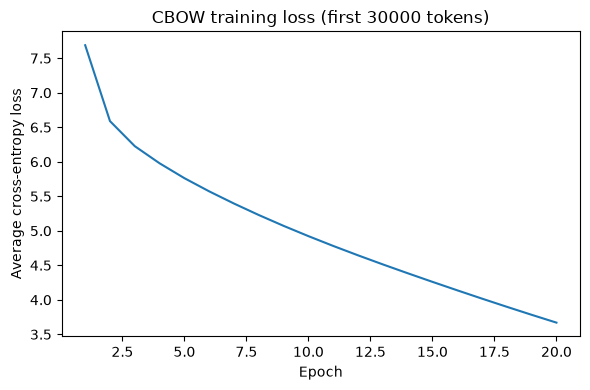

In [19]:
def train(training_pairs, word_to_int, vocab_size, embedding_dim=50,
          learning_rate=0.05, epochs=20):
    W1, W2 = init_params(vocab_size, embedding_dim)
    loss_history = []

    for epoch in range(epochs):
        total_loss = 0.0
        for context_words, target_word in training_pairs:
            context_idxs = [word_to_int[w] for w in context_words]
            target_idx = word_to_int[target_word]

            y_hat, h, u = forward(context_idxs, W1, W2)
            total_loss += cross_entropy_loss(y_hat, target_idx)

            dW1, dW2 = backward(y_hat, h, context_idxs, target_idx, W1, W2, vocab_size)
            W1, W2 = sgd_update(W1, W2, dW1, dW2, learning_rate)

        average_loss = total_loss / len(training_pairs)
        loss_history.append(average_loss)
        print(f"epoch {epoch + 1:2d}   average loss {average_loss:.4f}")

    return W1, W2, loss_history


embedding_dim = 50
learning_rate = 0.05
epochs = 20

np.random.seed(42)
W1, W2, loss_history = train(training_pairs, word_to_int, len(vocab),
                             embedding_dim=embedding_dim,
                             learning_rate=learning_rate,
                             epochs=epochs)

plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Average cross-entropy loss")
plt.title("CBOW training loss (first 30000 tokens)")
plt.tight_layout()
plt.show()


## Task 6: Evaluation

1. **Cosine similarity:** `cosine_similarity(v1, v2)`.
2. **Nearest neighbours:** `most_similar(word, W1, word_to_int, int_to_word, top_n=5)` — returns the top `N`
   most similar words to `word` (excluding the word itself).
3. **Test your model** on: `"harry"`, `"ron"`, `"magic"`, `"he"`, `"she"`.
4. **Analogy check:** using vector arithmetic
   ($v_{harry} - v_{he} + v_{she} \approx v_{?}$), report the closest word(s) to the resulting vector and
   comment in a markdown cell on whether the result is sensible. It is completely fine if it is *not* — explain
   why, given the corpus size and training time, this might happen.


In [20]:
def cosine_similarity(v1, v2):
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        return 0.0
    return float(np.dot(v1, v2) / denom)


def most_similar(word, W1, word_to_int, int_to_word, top_n=5):
    if word not in word_to_int:
        return []

    word_idx = word_to_int[word]
    target_vec = W1[word_idx]

    scores = []
    for idx in range(W1.shape[0]):
        if idx == word_idx:
            continue
        scores.append((int_to_word[idx], cosine_similarity(target_vec, W1[idx])))

    scores.sort(key=lambda pair: pair[1], reverse=True)
    return scores[:top_n]


test_words = ["harry", "ron", "magic", "he", "she"]

for w in test_words:
    print(w, "->")
    for neighbour, score in most_similar(w, W1, word_to_int, int_to_word, top_n=5):
        print(f"   {neighbour:>14s}  {score:.3f}")
    print()


harry ->
              ron  0.472
     enchantments  0.470
             them  0.456
              pan  0.393
               mr  0.359

ron ->
     enchantments  0.555
            goyle  0.542
        brilliant  0.530
           hagrid  0.512
             hmmm  0.508

magic ->
            sneer  0.591
        quidditch  0.545
         porridge  0.535
            these  0.509
              for  0.506

he ->
              pan  0.478
              yeh  0.423
        desperate  0.402
        footsteps  0.374
         scabbets  0.353

she ->
        desperate  0.552
            blame  0.526
           broken  0.509
     enchantments  0.504
           answer  0.479



In [21]:
def closest_words(vec, W1, int_to_word, exclude=(), top_n=5):
    scores = []
    for idx in range(W1.shape[0]):
        word = int_to_word[idx]
        if word in exclude:
            continue
        scores.append((word, cosine_similarity(vec, W1[idx])))

    scores.sort(key=lambda pair: pair[1], reverse=True)
    return scores[:top_n]


analogy_vec = W1[word_to_int["harry"]] - W1[word_to_int["he"]] + W1[word_to_int["she"]]

print("harry - he + she  ->")
for word, score in closest_words(analogy_vec, W1, int_to_word, exclude=("harry", "he", "she")):
    print(f"   {word:>14s}  {score:.3f}")


harry - he + she  ->
     enchantments  0.415
             them  0.414
               mr  0.413
              ron  0.382
             shut  0.378


**Your analysis (fill in):**

- Nearest neighbours found for each test word:
- Does the analogy result make sense? Why or why not?

**Answer:**

**Nearest neighbours found for each test word**

| Word | Top 5 neighbours (cosine) |
|---|---|
| harry | ron 0.472, enchantments 0.470, them 0.456, pan 0.393, mr 0.359 |
| ron | enchantments 0.555, goyle 0.542, brilliant 0.530, hagrid 0.512, hmmm 0.508 |
| magic | sneer 0.591, quidditch 0.545, porridge 0.535, these 0.509, for 0.506 |
| he | pan 0.478, yeh 0.423, desperate 0.402, footsteps 0.374, scabbets 0.353 |
| she | desperate 0.552, blame 0.526, broken 0.509, enchantments 0.504, answer 0.479 |

Three of these are genuinely right. `harry` has `ron` at the top, `ron` has `hagrid` in its list, and `magic`
has `quidditch`. Those are words that really do sit in the same kinds of sentences in the book. The rest is
noise. `enchantments` turns up in three of the five lists, which is the classic sign of an undertrained
embedding. It appears only a couple of times in 30,000 tokens, so its row barely moved from its random
initialisation and it ends up moderately close to everything.

**Does the analogy result make sense?**

No. `harry - he + she` returns `enchantments 0.415`, `them 0.414`, `mr 0.413`, `ron 0.382`, `shut 0.378`. No
female character appears, and the top four scores are bunched inside 0.04 of each other, which means the
arithmetic did not really select anything. It just returned whatever happened to be lying nearby.

This is what I would expect at this scale. The analogy needs gender to be a consistent direction in the
space, and such a direction only forms once the model has seen many male and female words used in matching
contexts. In this subset `he` appears 767 times but `she` only 88, so the "she" side of the direction is
estimated from about a tenth of the evidence and is mostly noise. The loss was also still at 3.67 and falling
steeply at epoch 20, so the space had not settled into any stable geometry yet. Vector arithmetic needs a far
better trained space than 30,000 tokens and 20 epochs can give, which is exactly why Part B used pretrained
GloVe vectors for the same demonstration.


## Task 7 (Bonus): Visualising the Embeddings

Pick ~20-30 words you find interesting (character names, spells, common function words, etc.), reduce their
embeddings to 2D with PCA (`sklearn.decomposition.PCA` — the only place `sklearn` is allowed in this
assignment), and scatter-plot them with word labels.


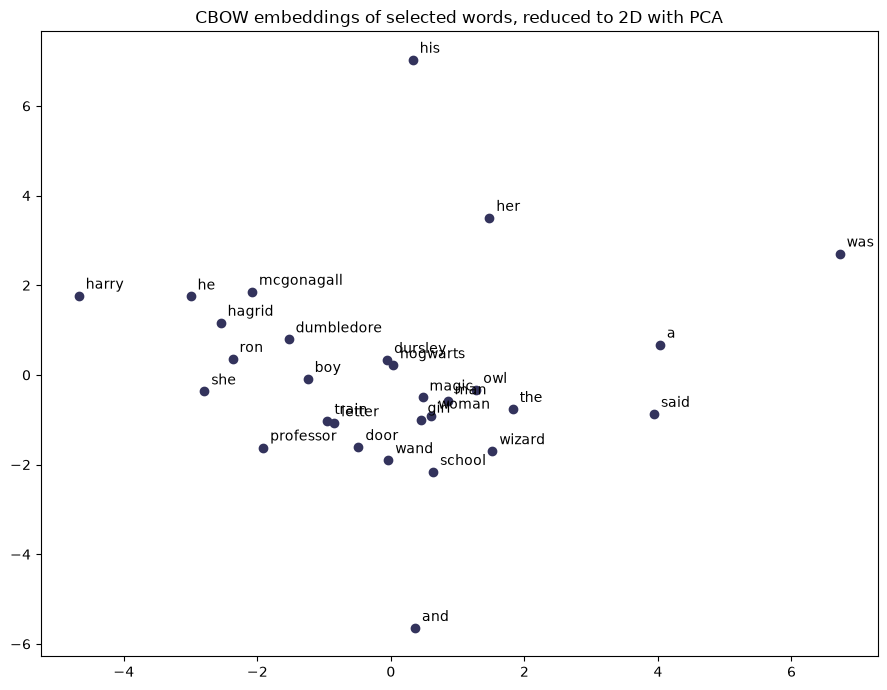

In [22]:
from sklearn.decomposition import PCA

plot_words = [
    "harry", "ron", "hagrid", "dumbledore", "dursley", "snape", "professor", "mcgonagall",
    "wizard", "magic", "wand", "owl", "school", "hogwarts", "letter", "train",
    "boy", "girl", "man", "woman", "he", "she", "his", "her",
    "the", "a", "and", "was", "said", "door",
]
plot_words = [w for w in plot_words if w in word_to_int]

plot_coords = PCA(n_components=2).fit_transform([W1[word_to_int[w]] for w in plot_words])

plt.figure(figsize=(9, 7))
plt.scatter(plot_coords[:, 0], plot_coords[:, 1], color="#33335c")
for word, (x, y) in zip(plot_words, plot_coords):
    plt.annotate(word, (x, y), textcoords="offset points", xytext=(5, 5))
plt.title("CBOW embeddings of selected words, reduced to 2D with PCA")
plt.tight_layout()
plt.show()


# Part D: Skip-gram from Scratch (Bonus)

CBOW predicts a **target** word from its surrounding **context**. Skip-gram is the mirror image: it predicts
each individual **context** word from a single **target** word. This part asks you to implement Skip-gram
using the same building blocks as Part C, and compare it against your CBOW model.

### Task D1: Generate Skip-gram training pairs

Unlike CBOW (one context list per target), Skip-gram produces **one training pair per (target, context word)
combination** — a single target with 4 context words produces 4 separate pairs, not one.

Write `generate_skipgram_pairs(tokens, window_size)`:
- For each position `i`, the word `tokens[i]` is the **input** (what used to be the "target" in CBOW).
- For every word `c` in its context window, emit a pair `(input_word, c)`.


In [23]:
def generate_skipgram_pairs(tokens, window_size):
    pairs = []
    for i in range(len(tokens)):
        left = tokens[max(0, i - window_size):i]
        right = tokens[i + 1:i + 1 + window_size]
        for c in left + right:
            pairs.append((tokens[i], c))
    return pairs


# --- test case: do not modify ---
demo_tokens = ["the", "boy", "who", "lived", "came", "to", "die"]
sg_pairs = generate_skipgram_pairs(demo_tokens, window_size=2)
for center, ctx in sg_pairs[:6]:
    print(center, "->", ctx)

# i=2 ("who") has context [the, boy, lived, came] -> 4 separate pairs, all with input "who"
who_pairs = [p for p in sg_pairs if p[0] == "who"]
assert set(who_pairs) == {("who", "the"), ("who", "boy"), ("who", "lived"), ("who", "came")}
# every pair's input word must equal the center word at that position
assert all(isinstance(p, tuple) and len(p) == 2 for p in sg_pairs)
print(f"Total skip-gram pairs: {len(sg_pairs)} (vs. {len(demo_tokens)} CBOW pairs from the same tokens)")


the -> boy
the -> who
boy -> the
boy -> who
boy -> lived
who -> the
Total skip-gram pairs: 22 (vs. 7 CBOW pairs from the same tokens)


### Task D2: Forward pass

Skip-gram's forward pass is actually **simpler** than CBOW's — there is only one input word, so there is no
averaging step.

$$
\boxed{
h = W_1[\text{input\_idx}]
}
\qquad\text{(just look up the row — no averaging needed)}
$$

$$
u = h\,W_2, \qquad \hat{y} = \mathrm{softmax}(u)
$$

Reuse your `stable_softmax` from Part C.


In [24]:
def skipgram_forward(input_idx, W1, W2):
    h = W1[input_idx]
    u = h @ W2
    y_hat = stable_softmax(u)
    return y_hat, h, u


# --- test case: do not modify ---
np.random.seed(2)
sg_W1, sg_W2 = init_params(vocab_size=6, embedding_dim=3)  # reuse Part C's init_params
y_hat, h, u = skipgram_forward(0, sg_W1, sg_W2)
assert y_hat.shape == (6,)
assert np.isclose(y_hat.sum(), 1.0, atol=1e-6)
assert np.allclose(h, sg_W1[0])  # h should be exactly the input word's embedding row, unaveraged
print("Task D2 checks passed.")


Task D2 checks passed.


### Task D3: Backward pass

Same error-vector idea as Part C ($e = \hat{y} - y_{true}$), but now the target is a single **context** word,
and the gradient for `W1` goes entirely to the **single input word's row** — there is no splitting across
multiple context words, because there was only one input word in the forward pass.

$$
e = \hat{y} - y_{true}, \qquad
\nabla W_2 = h^{\top} e, \qquad
\nabla h = W_2\, e
$$

$$
\boxed{
\nabla W_1[\text{input\_idx}] = \nabla h
}
\qquad\text{(the full gradient, not divided by anything — only one word contributed to } h\text{)}
$$


In [25]:
def skipgram_backward(y_hat, h, input_idx, context_idx, W1, W2, vocab_size):
    y_true = np.zeros(vocab_size)
    y_true[context_idx] = 1.0
    e = y_hat - y_true

    dW2 = np.outer(h, e)
    dh = W2 @ e

    dW1 = np.zeros_like(W1)
    dW1[input_idx] = dh

    return dW1, dW2


# --- test case: do not modify ---
np.random.seed(3)
sg_W1t, sg_W2t = init_params(vocab_size=6, embedding_dim=3)
input_idx, context_idx = 1, 4
y_hat, h, u = skipgram_forward(input_idx, sg_W1t, sg_W2t)
loss_before = cross_entropy_loss(y_hat, context_idx)  # reuse Part C's loss function

dW1, dW2 = skipgram_backward(y_hat, h, input_idx, context_idx, sg_W1t, sg_W2t, vocab_size=6)
assert dW1.shape == sg_W1t.shape
untouched_rows = [i for i in range(6) if i != input_idx]
assert np.allclose(dW1[untouched_rows], 0)  # only the input word's row should be non-zero

sg_W1t2, sg_W2t2 = sgd_update(sg_W1t.copy(), sg_W2t.copy(), dW1, dW2, learning_rate=0.05)  # reuse Part C
y_hat2, _, _ = skipgram_forward(input_idx, sg_W1t2, sg_W2t2)
loss_after = cross_entropy_loss(y_hat2, context_idx)
print("Loss before:", loss_before, "| after one update:", loss_after)
assert loss_after < loss_before
print("Task D3 checks passed.")


Loss before: 1.7920044804009323 | after one update: 1.791977556149755
Task D3 checks passed.


### Task D4: Train Skip-gram and compare with CBOW

Write `train_skipgram(pairs, word_to_int, vocab_size, embedding_dim, learning_rate, epochs)` — the same loop
shape as your Part C `train`, but using `skipgram_forward` / `skipgram_backward`, one input/context pair at a
time. Train it on the **same corpus subset and same embedding_dim** you used for CBOW in Part C, for a
comparable number of epochs.


Number of skip-gram training pairs: 119994
epoch  1   average loss 6.7886
epoch  2   average loss 6.1864
epoch  3   average loss 6.0240
epoch  4   average loss 5.9015
epoch  5   average loss 5.7896
epoch  6   average loss 5.6846
epoch  7   average loss 5.5872
epoch  8   average loss 5.4982
epoch  9   average loss 5.4174
epoch 10   average loss 5.3447
epoch 11   average loss 5.2795
epoch 12   average loss 5.2216
epoch 13   average loss 5.1707
epoch 14   average loss 5.1262
epoch 15   average loss 5.0878
epoch 16   average loss 5.0550
epoch 17   average loss 5.0274
epoch 18   average loss 5.0043
epoch 19   average loss 4.9853
epoch 20   average loss 4.9696


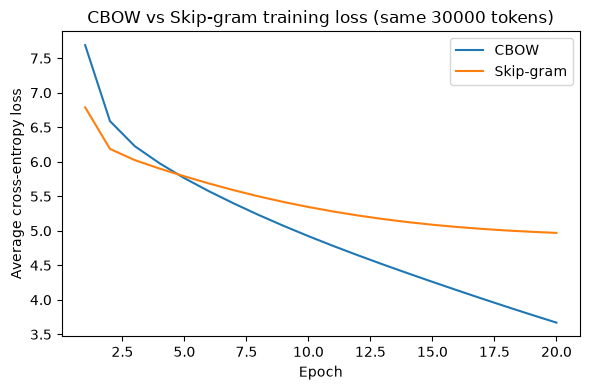

In [26]:
def train_skipgram(pairs, word_to_int, vocab_size, embedding_dim=50,
                    learning_rate=0.05, epochs=20):
    W1, W2 = init_params(vocab_size, embedding_dim)
    loss_history = []

    for epoch in range(epochs):
        total_loss = 0.0
        for input_word, context_word in pairs:
            input_idx = word_to_int[input_word]
            context_idx = word_to_int[context_word]

            y_hat, h, u = skipgram_forward(input_idx, W1, W2)
            total_loss += cross_entropy_loss(y_hat, context_idx)

            dW1, dW2 = skipgram_backward(y_hat, h, input_idx, context_idx, W1, W2, vocab_size)
            W1, W2 = sgd_update(W1, W2, dW1, dW2, learning_rate)

        average_loss = total_loss / len(pairs)
        loss_history.append(average_loss)
        print(f"epoch {epoch + 1:2d}   average loss {average_loss:.4f}")

    return W1, W2, loss_history


skipgram_training_pairs = generate_skipgram_pairs(tokens, window_size)
print(f"Number of skip-gram training pairs: {len(skipgram_training_pairs)}")

np.random.seed(42)
W1_sg, W2_sg, loss_history_sg = train_skipgram(skipgram_training_pairs, word_to_int, len(vocab),
                                               embedding_dim=embedding_dim,
                                               learning_rate=learning_rate,
                                               epochs=epochs)

plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), loss_history, label="CBOW")
plt.plot(range(1, epochs + 1), loss_history_sg, label="Skip-gram")
plt.xlabel("Epoch")
plt.ylabel("Average cross-entropy loss")
plt.title("CBOW vs Skip-gram training loss (same 30000 tokens)")
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
for w in test_words:
    cbow_neighbours = most_similar(w, W1, word_to_int, int_to_word, top_n=5)
    sg_neighbours = most_similar(w, W1_sg, word_to_int, int_to_word, top_n=5)

    print(w)
    print(f"   CBOW:      {[n for n, _ in cbow_neighbours]}")
    print(f"   Skip-gram: {[n for n, _ in sg_neighbours]}")
    print()


harry
   CBOW:      ['ron', 'enchantments', 'them', 'pan', 'mr']
   Skip-gram: ['ron', 'he', 'jokes', 'thirteen', 'sorcerer']

ron
   CBOW:      ['enchantments', 'goyle', 'brilliant', 'hagrid', 'hmmm']
   Skip-gram: ['harry', 'coolly', 'glancing', 'importantly', 'weird']

magic
   CBOW:      ['sneer', 'quidditch', 'porridge', 'these', 'for']
   Skip-gram: ['stuff', 'miles', 'solutions', 'anythin', 'carpets']

he
   CBOW:      ['pan', 'yeh', 'desperate', 'footsteps', 'scabbets']
   Skip-gram: ['mystery', 'ravenclaw', 'jokes', 'slytherin', 'hufflepuff']

she
   CBOW:      ['desperate', 'blame', 'broken', 'enchantments', 'answer']
   Skip-gram: ['impatiently', 'mighta', 'clear', 'casually', 'abnormal']



**Your comparison (fill in):**

- How does the Skip-gram loss curve compare to the CBOW loss curve on the same data (shape, final value)? If
  Skip-gram's loss plateaus noticeably higher, think about *why*: a frequent word produces the same input
  vector every time, but Skip-gram must predict several different context words from that one identical
  input — it can't outperform the natural entropy of that spread.
- Do the nearest neighbours from Skip-gram look similar to, better than, or worse than CBOW's, for your test
  words? Any words where one model clearly did better than the other?
- Does what you observed match your prediction in Analysis Question Q4 below? If not, what surprised you?

**Answer:**

- The two curves have clearly different shapes. CBOW starts at 7.69, drops fast for the first few epochs and
  is still falling in an almost straight line at epoch 20, ending at 3.67. Skip-gram starts lower at 6.79
  but flattens early and ends at 4.97, well above where CBOW finished. The reason is the one in the hint.
  CBOW averages up to four context embeddings, so its input is different for almost every training pair and
  it can push the loss on each pair down on its own. Skip-gram feeds the same single row for every
  occurrence of a word, and from that one identical input it has to predict `the`, then `boy`, then `lived`,
  then `came`. No weight setting makes all four correct at once, so the best it can do is spread the
  probability over the words that actually surround it, and the loss cannot drop below the entropy of that
  spread. Its curve settles onto a floor instead of heading towards zero.
- The neighbours are mixed. Skip-gram is better on the character names. `harry -> ron` and `ron -> harry` are
  mutual nearest neighbours, which CBOW never managed, and skip-gram's `harry` list also contains `he`. CBOW
  is better on `magic`, where it found `quidditch` while skip-gram returned `stuff` and `miles`. Skip-gram's
  `he` result is interesting in the wrong way, since it returned `ravenclaw`, `slytherin` and `hufflepuff`.
  The three house names have clearly clustered together, they are just sitting near the wrong query word.
  Neither model is good, and both lists still contain rare words that never really trained.
- It matches the Q4 prediction only in part. I expected skip-gram to handle rare words better, and it did
  win on `ron`, which appears 73 times against 485 for `harry`. But `magic` is the rarest of the five test
  words at 26 occurrences, and there CBOW was the one that found something sensible. So the prediction held
  for one word and failed for another. The real surprise was the size of the loss gap, because I had been
  reading a lower loss as a better model. On the same data those two numbers are not comparable at all,
  since CBOW and skip-gram are not solving the same prediction problem.


## Analysis Questions (write your answers in this cell)

**Q1. Loss curve.** Describe the shape of your training loss curve. Did it decrease smoothly, plateau, or
oscillate? What does that suggest about your learning rate?

**Q2. Corpus size vs. epochs.** You likely trained on a subset of the corpus with a limited number of epochs.
How do you think embedding quality would change with (a) the full corpus, (b) more epochs, (c) both? What
would the practical cost be?

**Q3. Softmax stability.** Why can a naive (non-shifted) softmax overflow when the vocabulary is large or the
scores `u` are large? Give a concrete example using numbers.

**Q4. CBOW vs. Skip-gram.** Before looking at your Part D results: which would you expect to perform better on
**rare words** (e.g. specific character names that appear only a few times), and why? Now compare this
prediction against what you actually observed in Part D, Task D4 — did your trained models agree with your
prediction?

**Q5. Limitations.** Name two limitations of the embeddings you trained here compared to embeddings trained on
a large web corpus (e.g. Google News word2vec), and explain the likely cause of each.

---

## Answers

**Q1. Loss curve.**

The CBOW curve falls smoothly with no oscillation at all. It drops steeply over the first few epochs, from
7.69 to 5.76 by epoch 5, then settles into a nearly straight downward line of about 0.12 per epoch and ends
at 3.67 at epoch 20 with no sign of levelling off. The first epoch average of 7.69 is already below
`log(3527) = 8.17`, the loss of a uniform guess over the vocabulary, so it was learning from the start.

A smooth curve with no bouncing means the learning rate of 0.05 is not too large. If it were, the average
loss would jump up and down between epochs as the updates overshot. The fact that it is still falling in a
straight line at the end says the opposite, that the rate is on the small side or that I simply stopped too
early. The model has not converged, it ran out of epochs. So the step size is in a stable range and the
training budget is what is limiting the result.

**Q2. Corpus size vs epochs.**

(a) *Full corpus.* Using all 80,624 tokens instead of 30,000 would give each word about 2.7 times more
updates and would grow the vocabulary from 3,527 to roughly 6,000, so words such as `hermione` and
`quidditch` that barely appear in my subset would get properly trained rows. This is the change that would
help most, because the failure I actually saw was embeddings that never moved from their random start.

(b) *More epochs.* My loss was still dropping steeply at epoch 20, so more epochs would keep improving it
for a while. There is a ceiling though. Extra passes over the same 30,000 tokens cannot reveal anything new
about a word that appeared twice, so beyond some point the model would only fit that small sample more
tightly while the rare word vectors stayed just as unreliable.

(c) *Both.* This is the real answer. More text supplies more distinct contexts per word and more epochs
supply enough updates to actually use them. Neither one fixes what the other is missing.

The practical cost is time. One CBOW epoch over 30,000 pairs took roughly ten seconds, and skip-gram, with
four times as many pairs, took around four times that. The cost scales with the number of pairs and with the
vocabulary size, because the softmax and both weight updates touch the whole of `W1` and `W2` on every
single example. Running the full book would push the vocabulary to about 6,000 and the pairs to 80,624, so
an epoch would cost roughly four to five times what it costs now, and skip-gram would multiply that again.
This is precisely the cost that negative sampling and hierarchical softmax were invented to remove, since
they replace the full softmax over the vocabulary with a handful of updates per step.

**Q3. Softmax stability.**

Softmax has to compute `exp(u_i)`. A `float64` tops out near `1.8e308`, and `exp(x)` crosses that once `x`
goes past about 709. So any score above 709 becomes `inf`, the denominator becomes `inf`, and `inf / inf`
gives `nan`. Nothing about the answer needed such a huge number. The correct probability was perfectly
ordinary, it is only the intermediate value that did not fit in the type.

Take `u = [1000, 999, 1]`:

- Naive softmax: `exp(1000) = inf`, `exp(999) = inf`, `exp(1) = 2.718`. The sum is `inf`, so the result is
  `[nan, nan, 0.0]` and training is dead from that point on.
- Shifted softmax: subtract `max(u) = 1000` to get `[0, -1, -999]`. Then `exp` gives `[1.0, 0.368, 0.0]`, the
  sum is 1.368, and the result is `[0.731, 0.269, 0.0]`, which is the correct answer.

Shifting is safe because `exp(u_i - c) / sum_j exp(u_j - c)` carries a factor `exp(-c)` on the top and the
bottom that cancels, so the probabilities do not change. Choosing `c = max(u)` makes the largest exponent
exactly 0, so nothing can overflow. The worst that can still happen is that a very negative entry underflows
to 0, which is harmless because its true probability was negligible anyway.

A large vocabulary makes the problem more likely simply because there are more scores. `u = h @ W2` produces
one score per vocabulary word, so with thousands of words there are thousands of chances for one to be
extreme, and a single `inf` is enough to poison the whole normalisation.

**Q4. CBOW vs Skip-gram.**

*Prediction, written before looking at Part D.* Skip-gram should do better on rare words. In CBOW a rare word
only ever appears as one member of a context that gets averaged, so its share of `h` is divided by the
context size and the gradient it receives is divided the same way. A frequent neighbour such as `the` sitting
in the same window dominates the average and smooths the rare word's signal away. In skip-gram the rare word
is the input by itself, `h` is exactly its row, and it takes the entire gradient. It also produces one
training pair per context word instead of being one part of a single pair, so it appears in the training
stream more often.

*What I actually observed.* Partly right. On `ron`, which appears 73 times against 485 for `harry`,
skip-gram was clearly better and made `harry` and `ron` mutual nearest neighbours, something CBOW never
managed. But `magic` is the rarest of the five test words at 26 occurrences, and there CBOW won, finding
`quidditch` while skip-gram returned `stuff` and `miles`. So the prediction held on one word and failed on
another. At 30,000 tokens and 20 epochs neither model is trained well enough for the architectural
difference to show through the noise reliably, and five test words is far too small a sample to settle it.

**Q5. Limitations.**

*1. Almost every word is rare.* The 30,000 token subset has 3,527 distinct words and most of them appear only
once or twice. A word appearing twice has its embedding row touched by a couple of gradient updates per
epoch, so it never really leaves its `randn * 0.01` starting point. Google News word2vec was trained on
roughly 100 billion tokens, where even an uncommon word still appears thousands of times. The cause is
purely the amount of evidence per word. A cosine between two barely trained rows measures leftover random
initialisation rather than meaning, which is why words like `enchantments` kept appearing in unrelated
neighbour lists.

*2. The vocabulary and the word senses come from one novel.* Anything the book does not mention has no vector
at all, so the model cannot represent ordinary words such as `computer` or `election`. Words that are present
only carry the sense the story uses, so `wand`, `owl` and `professor` are shaped entirely by Hogwarts, and a
word like `bank` would mean only whatever it meant in the one sentence it appeared in. The cause is the
single narrow domain. A vector is a summary of the contexts a word was seen in, so a corpus from one author
and one genre gives a summary that does not transfer anywhere else, while a news corpus spanning many topics
averages over the different ways each word is really used.
